<a href="https://colab.research.google.com/github/Lavish05563/california-housing-regression/blob/main/task1_ml_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported successfully!

--- First 5 Rows of Features ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


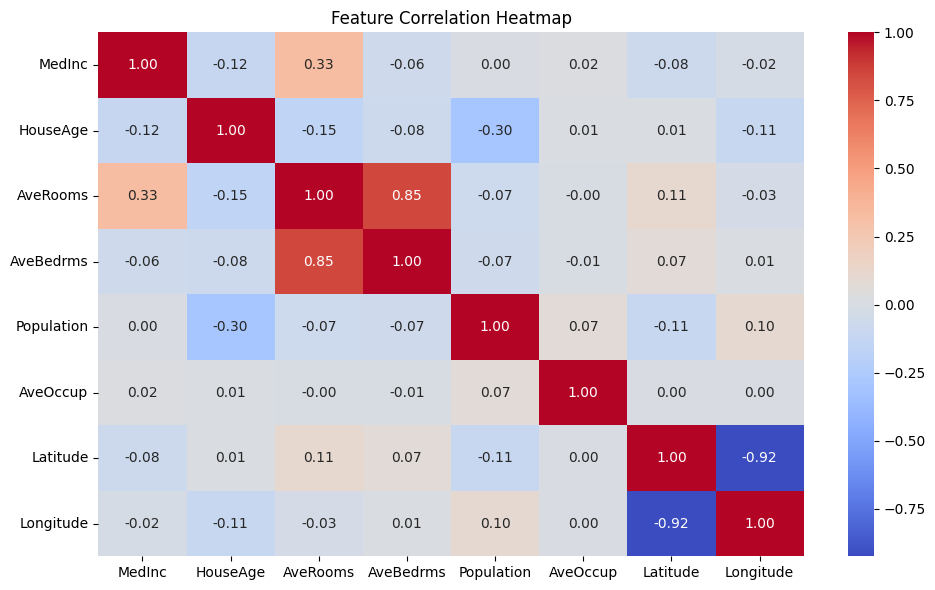

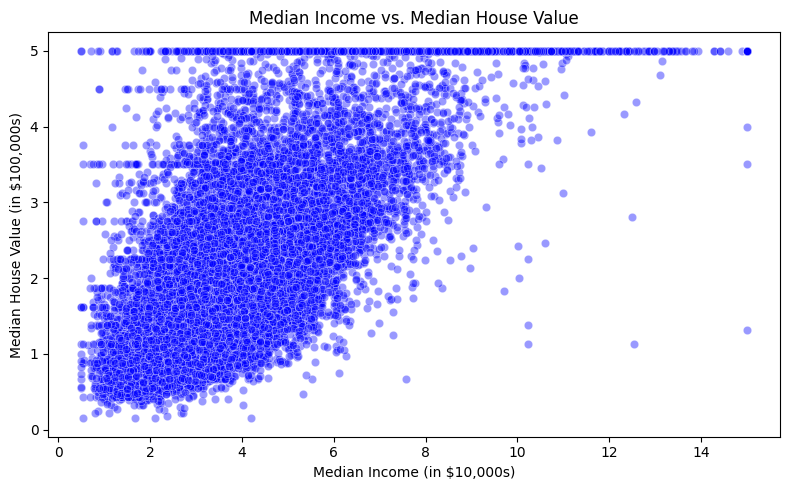


Data split successfully. Training size: 16512, Test size: 4128
Linear Regression model trained successfully!

--- Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 0.7456
R-squared (R2) Score: 0.5758

'model.pkl' and 'scaler.pkl' files saved successfully!


In [1]:
# =====================================================================
# DELIVERABLE 1: JUPYTER NOTEBOOK (task1_ml_linear_regression.ipynb)
# =====================================================================

# 1. Importing Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

# 2. Loading the California Housing Dataset
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target  # Target Variable: MedHouseVal (Median House Value)

# Displaying first 5 rows of the dataset
print("\n--- First 5 Rows of Features ---")
print(X.head())

# 3. Exploratory Data Analysis (EDA) - Generating Plots
# Plot 1: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Plot 2: Scatter Plot of Median Income vs Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X['MedInc'], y=y, alpha=0.4, color='blue')
plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('Median House Value (in $100,000s)')
plt.title('Median Income vs. Median House Value')
plt.tight_layout()
plt.show()

# 4. Data Splitting (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nData split successfully. Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 5. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Model Training (Linear Regression)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Linear Regression model trained successfully!")

# 7. Model Evaluation Metrics
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 8. DELIVERABLE 3: Saving Model and Scaler as Pickle Files
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n'model.pkl' and 'scaler.pkl' files saved successfully!")